In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# 1. Create a Time Range (365 days)
days = np.arange(0, 365)

In [5]:
# 2. Create the Components
trend = days * 0.1                # Linear growth (Gradient)
seasonality = 10 * np.sin(days * (2 * np.pi / 30))  # Sine wave (Monthly cycle)
noise = np.random.normal(0, 2, 365) # Random static

In [6]:
# 3. Combine them
data = trend + seasonality + noise

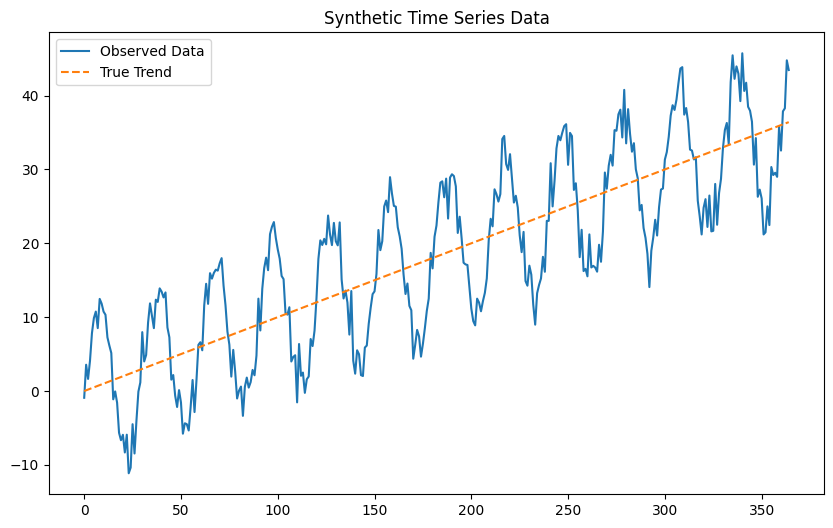

In [7]:
# 4. Plot
plt.figure(figsize=(10, 6))
plt.plot(days, data, label='Observed Data')
plt.plot(days, trend, label='True Trend', linestyle='--')
plt.title("Synthetic Time Series Data")
plt.legend()
plt.show()

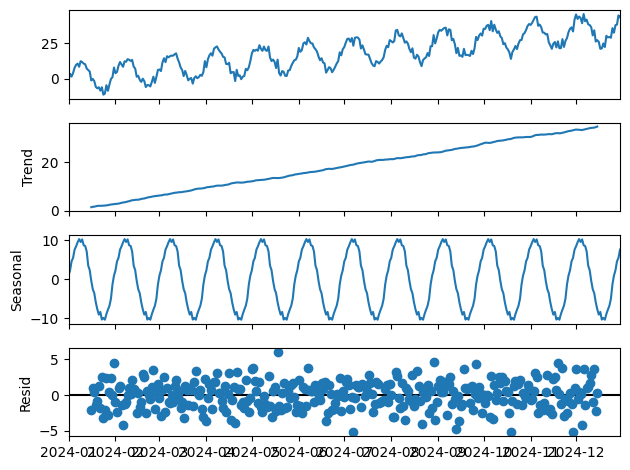

In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose

# We have to convince pandas that this is time-series data
# We are creating a fake date range starting from Jan 1st
dates = pd.date_range(start='2024-01-01', periods=365, freq='D')
series = pd.Series(data, index=dates)

# Decompose the data
# model='additive' because Y = Trend + Seasonality + Noise
result = seasonal_decompose(series, model='additive', period=30)

# Plot the 4 separated graphs
result.plot()
plt.show()

In [10]:
from statsmodels.tsa.stattools import adfuller

# 1. Get the residuals (The noise left over)
residuals = result.resid.dropna()

# 2. Run the ADF Test
adf_test = adfuller(residuals)

# 3. Print the results clearly
print(f"ADF Statistic: {adf_test[0]}")
print(f"P-Value:       {adf_test[1]}")
print("--------------------------------")
if adf_test[1] < 0.05:
    print("RESULT: STRONG EVIDENCE the residuals are Stationary (Good).")
    print("We successfully removed the Trend and Seasonality.")
else:
    print("RESULT: WEAK EVIDENCE. The residuals are NOT Stationary (Bad).")
    print("There is still a pattern hidden in the noise.")

ADF Statistic: -7.409236908799078
P-Value:       7.207247547122637e-11
--------------------------------
RESULT: STRONG EVIDENCE the residuals are Stationary (Good).
We successfully removed the Trend and Seasonality.


In [21]:
a = 366*0.1 + 10 * np.sin(366 * (2 * np.pi / 30))

a.item()

46.1105651629515

<Figure size 1000x600 with 0 Axes>

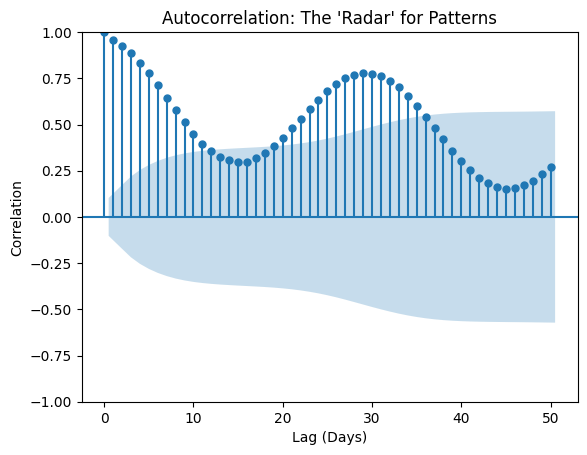

In [22]:
from statsmodels.graphics.tsaplots import plot_acf

# We look at the first 50 lags (days)
# If there is a 30-day cycle, we must see a spike at x=30
plt.figure(figsize=(10, 6))
plot_acf(series, lags=50)
plt.title("Autocorrelation: The 'Radar' for Patterns")
plt.xlabel("Lag (Days)")
plt.ylabel("Correlation")
plt.show()

<Figure size 1000x600 with 0 Axes>

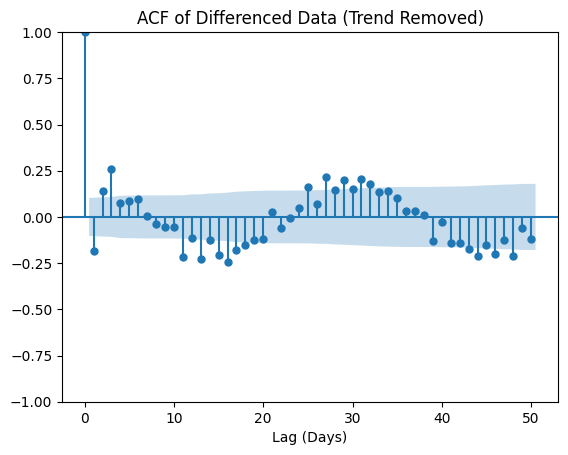

In [23]:
# 1. Kill the Trend (First Order Differencing)
# This creates a new series of "Changes" instead of "Values"
diff_series = series.diff().dropna()

# 2. Check the Radar again
plt.figure(figsize=(10, 6))
plot_acf(diff_series, lags=50)
plt.title("ACF of Differenced Data (Trend Removed)")
plt.xlabel("Lag (Days)")
plt.show()

In [28]:
# ==============PRIDICTION Starts Hear================= #

In [29]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [30]:
# 1. Define the Model
# order=(p, d, q) -> Non-seasonal parameters
# seasonal_order=(P, D, Q, s) -> Seasonal parameters (s=30 is crucial here)
model = SARIMAX(series, 
                order=(1, 1, 1), 
                seasonal_order=(1, 1, 1, 30))

In [31]:
# 2. Train the Model (Fit it to the data)
print("Training model... this might take a second...")
model_fit = model.fit(disp=False)

Training model... this might take a second...


In [32]:
# 3. Forecast the next 30 days
forecast = model_fit.forecast(steps=30)

In [33]:
# 4. Compare Day 366 Prediction
predicted_366 = forecast.iloc[0]
print(f"------------------------------------------------")
print(f"Manual Math Prediction (Cheating): 46.11")
print(f"SARIMA Model Prediction (Real AI): {predicted_366:.2f}")
print(f"------------------------------------------------")

------------------------------------------------
Manual Math Prediction (Cheating): 46.11
SARIMA Model Prediction (Real AI): 44.51
------------------------------------------------


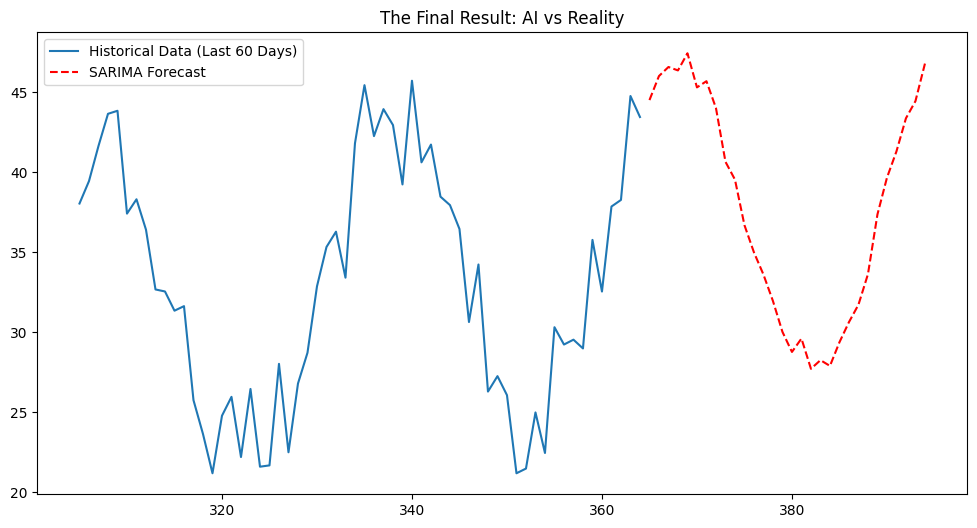

In [34]:
# 5. Visual Proof
plt.figure(figsize=(12, 6))
plt.plot(days[-60:], data[-60:], label='Historical Data (Last 60 Days)')
plt.plot(np.arange(365, 395), forecast, label='SARIMA Forecast', color='red', linestyle='--')
plt.title("The Final Result: AI vs Reality")
plt.legend()
plt.show()